In [1]:
import cartopy.crs as ccrs
import xarray as xr
import pandas as pd
import numpy as np
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from matplotlib import pyplot as plt
import matplotlib.colors as colors
import glob
import matplotlib
%matplotlib inline

rho_w=997
g=9.8

In [46]:
ERA5_SFC_DIR='/data/dadm1/reanalysis/ERA5/SFC/day'
ERA5_PRS_DIR='/data/dadm1/reanalysis/ERA5/PRS/day'
IMERG_DIR='/data/dadm1/obs/GPM_IMERG/GPM_3IMERGHH.07/'

#define focusing region
[min_lon, max_lon, min_lat, max_lat]=[105.,135.,5.,30.]
#[min_lon, max_lon, min_lat, max_lat]=[90.,140.,0.,40.]
slp_levels=np.linspace(980,1040,16)
slp_lws=[2 if (pp-980)%20==0 else 1 for pp in slp_levels]
cwv_cmap=colors.LinearSegmentedColormap.from_list('cwv_cmap',plt.cm.Blues(np.linspace(0.0,0.5,21)))

In [47]:
dateStr='20110702'
dTime=pd.to_datetime(dateStr)
doy=dTime.dayofyear
print('%s is %d day of year %d/%02d/%02d'%(dateStr,doy, dTime.year, dTime.month, dTime.day))

20110702 is 183 day of year 2011/07/02


In [48]:
#IMERG
ds=xr.open_mfdataset('/data/dadm1/obs/GPM_IMERG/GPM_3IMERGHH.07/%04d/%03d/*'%(dTime.year,doy),group='/Grid')\
        .sel(lat=slice(min_lat-1,max_lat+1),lon=slice(min_lon-1,max_lon+1))
daily_preci=ds['precipitation'].mean(dim='time').values
lon_preci=ds['lon'].values
lat_preci=ds['lat'].values
print(daily_preci.shape,lon_preci.shape,lat_preci.shape)
#ERA5 wind field at 925mb
def getEARA5(dataDir,dTime,var,lev=None):
    fname=glob.glob('%s/%s/%04d/*%04d%02d*'%(dataDir,var,dTime.year,dTime.year,dTime.month))[0]
    ds=xr.open_dataset(fname,engine='netcdf4')
    ds=ds.reindex(latitude=list(reversed(ds.latitude))).sel(latitude=slice(min_lat-1,max_lat+1),longitude=slice(min_lon-1,max_lon+1))
    if lev:
        ds=ds.sel(level=lev)
    return ds.isel(time=dTime.day-1)

u925=getEARA5(ERA5_PRS_DIR,dTime,'u',lev=850.0).u.values
v925=getEARA5(ERA5_PRS_DIR,dTime,'v',lev=850.0).v.values
h500=getEARA5(ERA5_PRS_DIR,dTime,'z',lev=500.0).z.values/g
ds=getEARA5(ERA5_PRS_DIR,dTime,'q')
levs=ds.level.values
lon=ds.longitude.values
lat=ds.latitude.values
qv=ds.q.values
mslp=getEARA5(ERA5_SFC_DIR,dTime,'msl').msl.values/100.0

(320, 270) (320,) (270,)


In [49]:
print(u925.shape,v925.shape,qv.shape,mslp.shape,lon.shape,lat.shape)

(109, 129) (109, 129) (37, 109, 129) (109, 129) (129,) (109,)


In [50]:
#get data to plot
ws925=np.sqrt(u925*u925+v925*v925)
xx,yy=np.meshgrid(lon,lat)

cwv=np.sum(-qv[1:,:,:]*(levs[:-1]-levs[1:]).reshape((-1,1,1))*100.0/g/rho_w*1000.0,axis=0)

print(qv.shape,levs)

(37, 109, 129) [   1.    2.    3.    5.    7.   10.   20.   30.   50.   70.  100.  125.
  150.  175.  200.  225.  250.  300.  350.  400.  450.  500.  550.  600.
  650.  700.  750.  775.  800.  825.  850.  875.  900.  925.  950.  975.
 1000.]


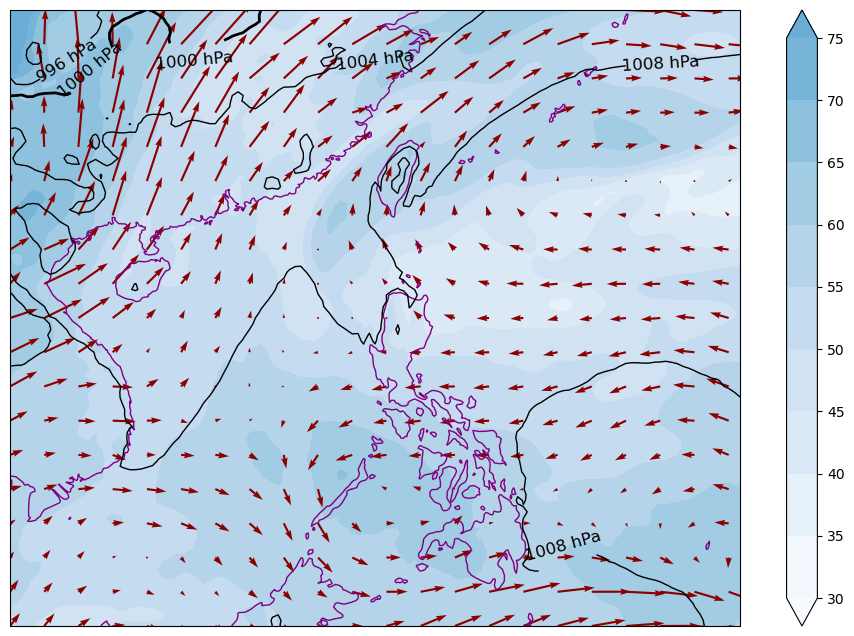

In [51]:
skip=6
plt.close()
plt.figure(figsize=(12,8))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
cf=ax.contourf(lon, lat, cwv, levels=np.linspace(30,75,10), extend='both', transform=ccrs.PlateCarree(),cmap=cwv_cmap)
#c500=ax.contour(lon, lat, h500, levels=[5760,5820,5880],transform=ccrs.PlateCarree(),colors='k')
#ax.clabel(c500, c500.levels, inline=True, fmt='%.0f m', fontsize=12)
plt.quiver(xx[::skip,::skip],yy[::skip,::skip],u925[::skip,::skip],v925[::skip,::skip],color='darkred',transform=ccrs.PlateCarree())
#ax.contour(lon_preci, lat_preci, daily_preci.T, transform=ccrs.PlateCarree())
c_mslp=ax.contour(lon, lat, mslp,levels=slp_levels, linewidths=slp_lws, colors='k', transform=ccrs.PlateCarree())
ax.clabel(c_mslp, slp_levels, inline=True, fmt='%.0f hPa', fontsize=12)
ax.coastlines(color='purple')
plt.colorbar(cf)


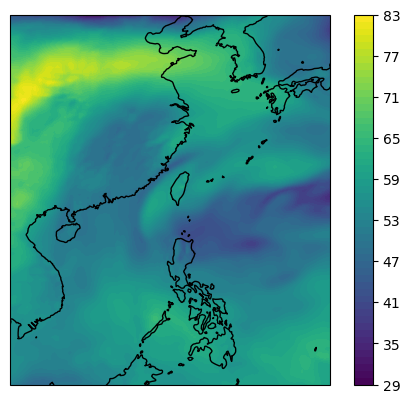

In [29]:
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
plt.contourf(lon, lat, cwv, 60, transform=ccrs.PlateCarree())
ax.coastlines(color='purple')
plt.colorbar()

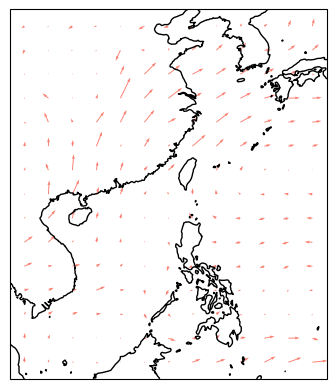

In [45]:
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
q1=plt.quiver(lon[::10], lat[::10], u925[::10,::10], v925[::10,::10], transform=ccrs.PlateCarree(),
                        scale=250,color='salmon',width=0.003)
ax.coastlines()


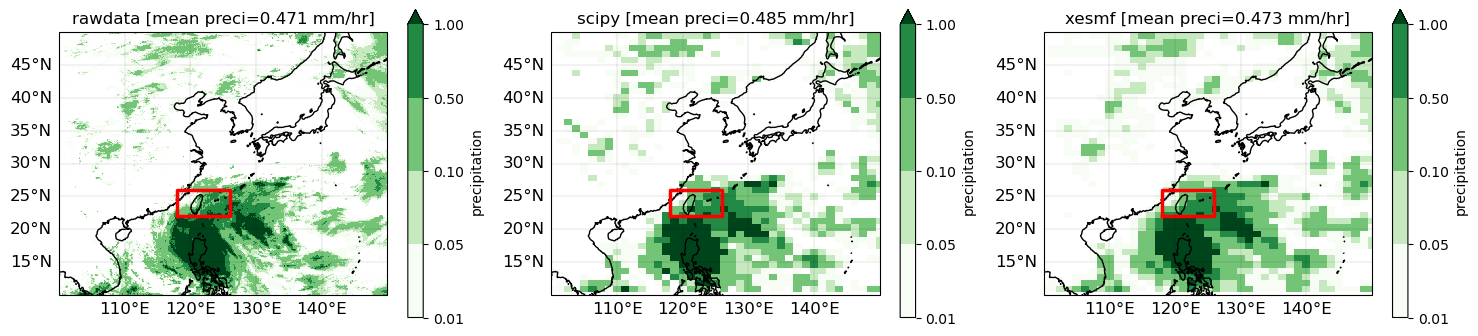

In [28]:
[min_lon_tw, max_lon_tw, min_lat_tw, max_lat_tw]=[105.,135.,5.,40.]
# Defining the figure
plt.close()
fig,axes = plt.subplots(1,3,subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)},
                          figsize=(18,4),sharex=True, facecolor='w', edgecolor='k')

for i,(lbl,data) in enumerate(zip(['rawdata','scipy','xesmf'],
                                    [daily_preci,preci_interp,preci_xesmf])):
    data_tw=data.sel(lat=slice(min_lat_tw,max_lat_tw),lon=slice(min_lon_tw,max_lon_tw))
    meanPrec=data_tw.values.mean()
    data_asia=data.sel(lat=slice(min_lat,max_lat), lon=slice(min_lon,max_lon))
    #print(lbl,data_asia.max().compute(),data_asia.min().compute())

    data_asia.plot(ax=axes[i],x='lon',y='lat',transform=ccrs.PlateCarree(),\
                                      levels=[0.01,0.05,0.1,0.5,1.0],extend='max',cmap='Greens')
    axes[i].coastlines(linewidth=1)
    axes[i].set_extent([min_lon, max_lon, min_lat, max_lat], ccrs.PlateCarree())
    axes[i].set_title('%s [mean preci=%.3f mm/hr]'%(lbl,meanPrec))
    axes[i].plot([min_lon_tw, max_lon_tw,max_lon_tw,min_lon_tw,min_lon_tw],\
                 [min_lat_tw,min_lat_tw, max_lat_tw,max_lat_tw,min_lat_tw],\
                 lw=2.5,color='r',transform=ccrs.PlateCarree())
    # Plot lat/lon grid
    gl = axes[i].gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=0.1, color='k', alpha=1,
                  linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 12}
    gl.ylabel_style = {'size': 12}
